In [1]:
!pip install scanpy
!pip install scanpy umap-learn
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 78.8 MB/s eta 0:00:00


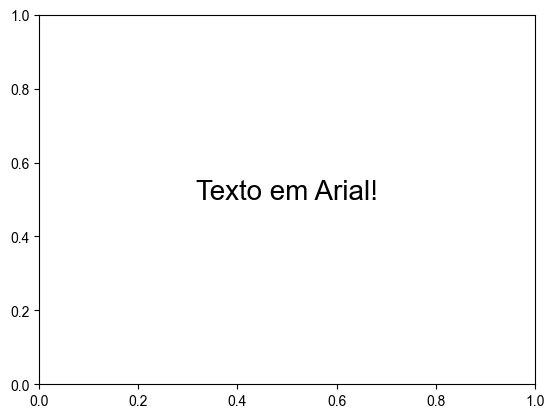

In [2]:
from matplotlib import font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt

font_path = "/content/ARIAL.TTF"

fm.fontManager.addfont(font_path)

mpl.rcParams['font.family'] = 'Arial'

plt.text(0.5, 0.5, "Texto em Arial!", fontsize=20, ha='center')

plt.show()

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns

In [4]:
plt.rcParams['axes.labelsize'] = 26
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['font.family'] = 'Arial'

CTL, N0, N1:

In [37]:
condition_colors = {
    "Control_OLDC":"#feedde", #CTL - Plate 1
    "N0_EPF": "#fdbe85",      #N0 - Plate 2
    "Nodal_metastasis_VM":"#ea8500ff" #N1 - Plate 3
}

In [38]:
file_path = "Busca1_Saliva_Cryopreserved_Patients_Library_Report.tsv"
data = pd.read_csv(file_path, sep="\t", encoding='latin-1')

original_col_count = data.shape[1]
data = data.loc[:, (data != 0).sum() >= 0]

filtered_col_count = data.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


In [39]:

exclude_df = pd.read_excel("Blanks_Common.xlsx")

ids_to_exclude = exclude_df.iloc[:, 0].tolist()

data = data[~data.iloc[:, 0].isin(ids_to_exclude)]

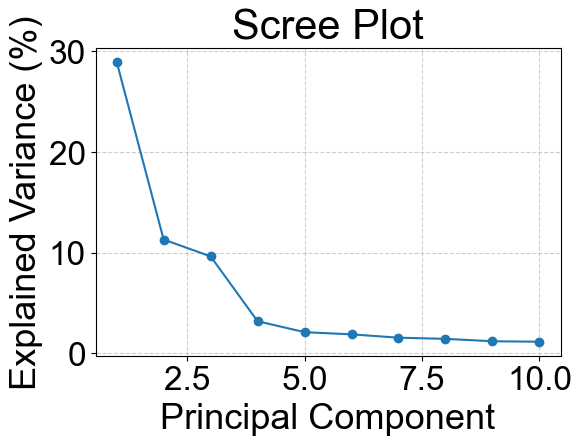

In [40]:
transposed_data = data.set_index("PG.Genes").transpose()

transposed_data = transposed_data.fillna(0)

valid_samples = [sample for sample in transposed_data.index if "_" in sample]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(row) for row in transposed_data.index]

colors = [condition_colors.get(condition, "#000000") for condition in sample_conditions]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=10)

explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance_ratio)+1),
         explained_variance_ratio*100, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

transposed_data.to_csv("Saliva_Cryopreserved_Patients_Library_Report_transposed.tsv", sep="\t")

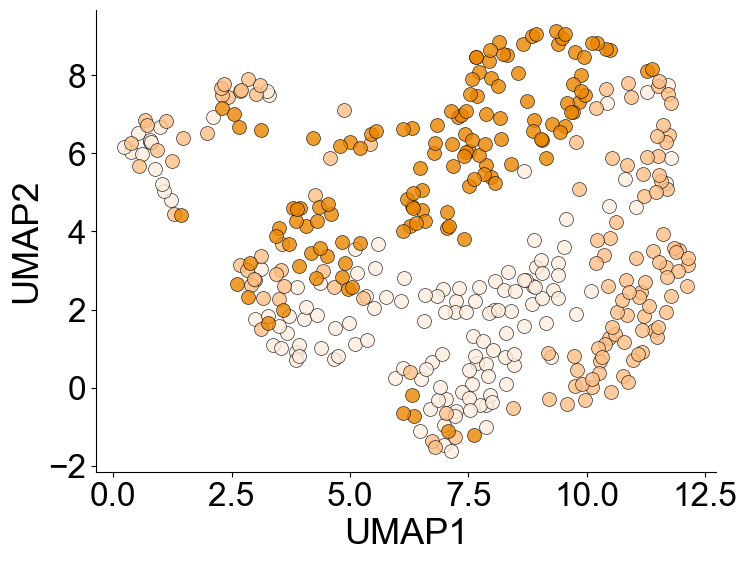

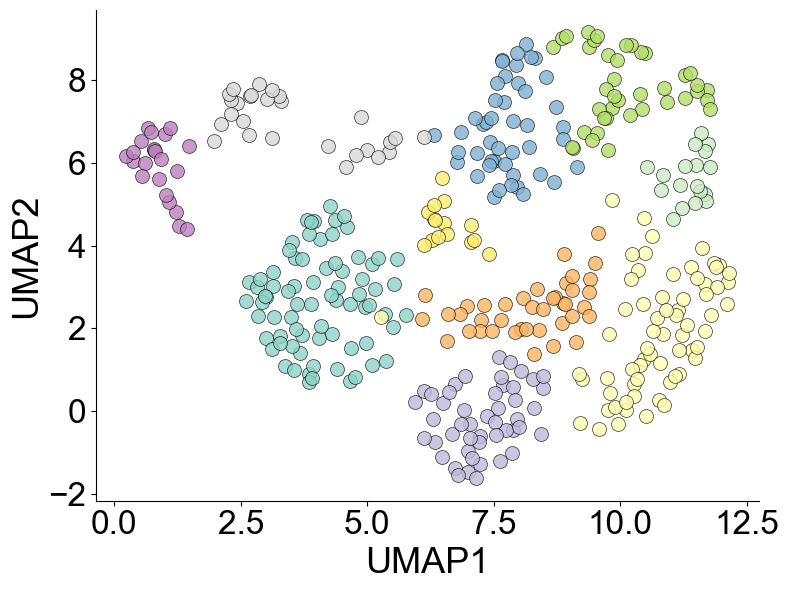

In [41]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]
filtered_data = transposed_data.loc[valid_samples]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(sample) for sample in valid_samples]

obs_data = pd.DataFrame({"condition": sample_conditions}, index=valid_samples)

adata = sc.AnnData(filtered_data.values, obs=obs_data, var=pd.DataFrame(index=filtered_data.columns))

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=10)
sc.pp.neighbors(adata)

sc.tl.leiden(adata, resolution=1)


sc.tl.umap(adata, random_state=42)

umap_results = adata.obsm["X_umap"]
umap1 = umap_results[:, 0]
umap2 = umap_results[:, 1]




plt.figure(figsize=(8, 6))
for condition in np.unique(sample_conditions):
    mask = obs_data["condition"] == condition
    plt.scatter(umap1[mask], umap2[mask], label=condition,
                color=condition_colors.get(condition, "#000000"),
                alpha=0.8, s=100, edgecolor='black', linewidth=0.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(False)
plt.savefig("umap_condition_clean_axes.svg", dpi=300)

plt.show()

leiden_labels = adata.obs["leiden"]
palette = plt.cm.Set3(np.linspace(0, 1, len(sorted(leiden_labels.unique()))))

plt.figure(figsize=(8, 6))
for i, cluster in enumerate(sorted(leiden_labels.unique())):
    mask = leiden_labels == cluster
    plt.scatter(
        umap1[mask], umap2[mask],
        s=100, alpha=0.8, edgecolor='black', linewidth=0.5,
        color=palette[i]
    )

plt.xlabel("UMAP1", color='black')
plt.ylabel("UMAP2", color='black')

plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')


plt.tight_layout()
plt.savefig("leiden_clean_axes.svg", dpi=300)
plt.show()

In [45]:
group_counts = adata.obs.groupby(["condition", "leiden"]).size().unstack(level="leiden", fill_value=0)

print("Number of cells per Leiden cluster within each condition:")
print(group_counts)

Number of cells per Leiden cluster within each condition:
leiden                0   1   2   3   4   5   6   7   8   9
condition                                                  
Control_OLDC         31   4  37   1  40   3   3  12   4   0
N0_EPF               16  62   6   0   0   9  13   9  14   0
Nodal_metastasis_VM  28   0   5  45   0  28  11   1   0  15


/tmp/ipython-input-207943466.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = adata.obs.groupby(["condition", "leiden"]).size().unstack(level="leiden", fill_value=0)


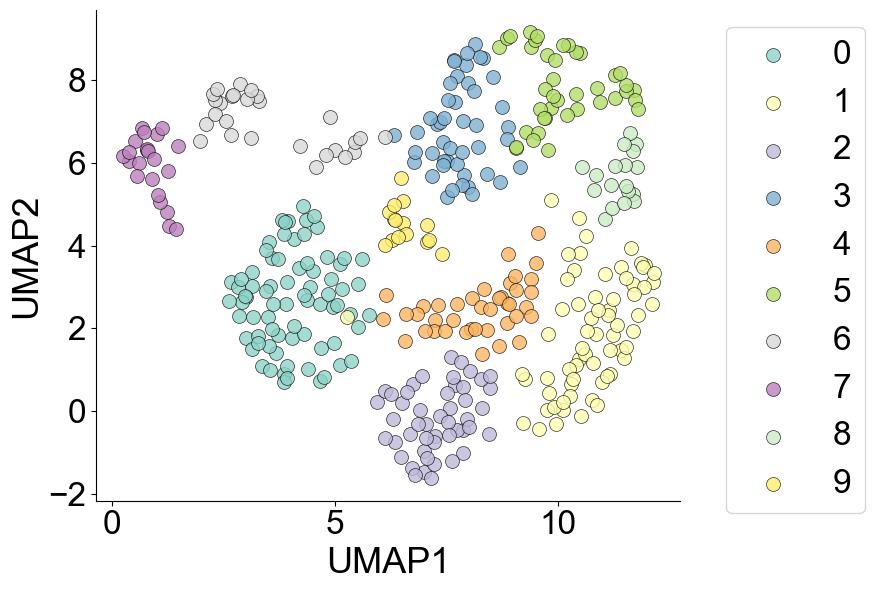

In [46]:
#Legend
leiden_labels = adata.obs["leiden"]
palette = plt.cm.Set3(np.linspace(0, 1, len(sorted(leiden_labels.unique()))))

plt.figure(figsize=(8.9, 6))
for i, cluster in enumerate(sorted(leiden_labels.unique())):
    mask = leiden_labels == cluster
    plt.scatter(
        umap1[mask], umap2[mask],
        label=f"{cluster}",
        s=100, alpha=0.8, edgecolor='black', linewidth=0.5,
        color=palette[i]
    )

plt.xlabel("UMAP1", color='black')
plt.ylabel("UMAP2", color='black')

plt.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.tight_layout()
plt.savefig("leiden_with_legend.svg", dpi=300)
plt.show()


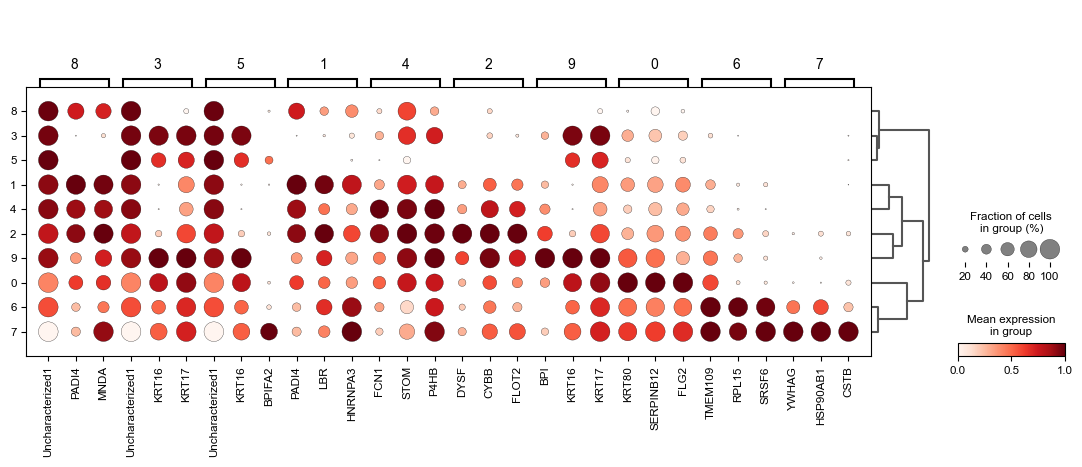

In [48]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

marker_genes = []
groups = adata.obs["leiden"].unique().tolist()

for group in groups:
    df = sc.get.rank_genes_groups_df(adata, group=group, key="dea_leiden")
    df = df.dropna(subset=["logfoldchanges", "pvals"])
    df = df[df["pvals_adj"] < 0.05]
    df = df.nlargest(5, "scores")
    marker_genes.extend(df["names"].tolist())

marker_genes = list(dict.fromkeys(marker_genes))

adata.var_names_make_unique()

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df["fold_change"] = 2 ** full_df["logfoldchanges"]
full_df.to_csv("DEG_leiden_with_FC.tsv", sep="\t", index=False)

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden",
    key="dea_leiden",
    n_genes=3, # Keep n_genes=5 to show top 5 per group
    standard_scale="var",
    dendrogram=True,
    cmap="Reds",
    show=True,
    save="_PG_dotplot_leidengroup_markers.svg"
)

In [49]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]


cluster_dict = {group: set(full_df[full_df["group"] == group]["names"])
                for group in adata.obs["leiden"].unique()}


exclusive_genes = {}
for group, genes in cluster_dict.items():
    other_genes = set().union(*[g for gname, g in cluster_dict.items() if gname != group])
    exclusive_genes[group] = genes - other_genes

exclusive_df = [(group, gene) for group, genes in exclusive_genes.items() for gene in genes]
exclusive_df = pd.DataFrame(exclusive_df, columns=["cluster", "gene"])
exclusive_df.to_csv("exclusive_genes_per_cluster.tsv", sep="\t", index=False)

exclusive_genes


{'0': {'GGH', 'HEXB'},
 '2': {'ALDH3B1',
  'ATP8A1',
  'C4BPA',
  'FCER1G',
  'FCGR3B',
  'FGR',
  'HK3',
  'SIRPA',
  'TCIRG1',
  'UNC13D'},
 '4': set(),
 '7': {'ACOT9',
  'ACSL3',
  'ANXA8',
  'AP1B1',
  'APOA1',
  'ARHGAP1',
  'ARHGDIB',
  'ARRB2',
  'BRK1',
  'CAP1',
  'CDC42',
  'COTL1',
  'CSTB',
  'DEF6',
  'DMBT1',
  'EFHD2',
  'ELMO1',
  'EPRS1',
  'ESYT1',
  'FASN',
  'FERMT3',
  'FGA',
  'FGG',
  'G6PD',
  'GLTP',
  'GMFG',
  'GSTO1',
  'H6PD',
  'HLA-DRB3',
  'IGHM',
  'IMPDH2',
  'KCTD12',
  'KRT4',
  'LGALS3BP',
  'LPO',
  'LTA4H',
  'MARCKS',
  'MUC5B',
  'MYADM',
  'NAMPT',
  'NIBAN2',
  'NSF',
  'NUCB1',
  'PA2G4',
  'PAFAH1B1',
  'PGD',
  'PSMC4',
  'PSMD2',
  'PTGR1',
  'PYGL',
  'RARS1',
  'RPL34',
  'SAR1A',
  'SEC22B',
  'SERPINB5',
  'SHTN1',
  'SKP1',
  'SMC3',
  'SPRR3',
  'SPTAN1',
  'SUB1',
  'TUBB2A',
  'USO1',
  'USP5',
  'USP7',
  'VSIG10L',
  'WARS1',
  'WDR1'},
 '1': {'MMP8', 'MMP9'},
 '6': {'ACAA2', 'ANPEP', 'CES1', 'ECH1', 'KHSRP', 'MECP2', 'STAT1'},
 

Exclusise selected: {'0': ['GGH', 'HEXB'], '2': ['ALDH3B1', 'UNC13D', 'TCIRG1', 'ATP8A1', 'FGR'], '7': ['CSTB', 'CDC42', 'ARHGAP1', 'NAMPT', 'PGD'], '1': ['MMP9', 'MMP8'], '6': ['KHSRP', 'ACAA2', 'ECH1', 'CES1', 'ANPEP'], '5': ['CTSS']}
categories: 0, 1, 2, etc.
var_group_labels: 0, 2, 7, etc.


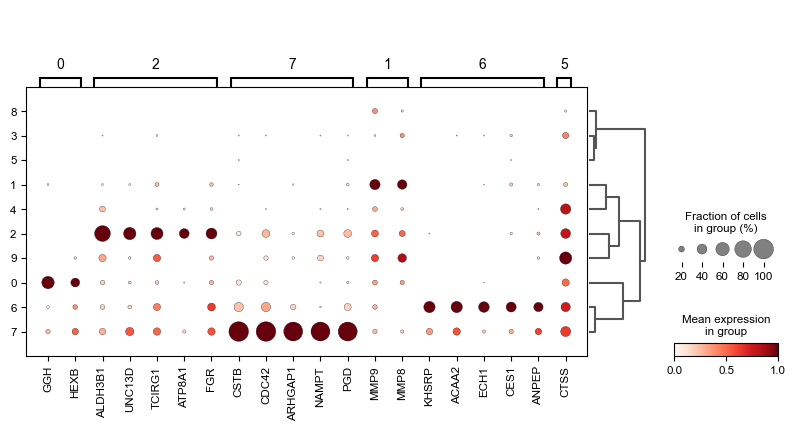

In [50]:
import scanpy as sc
import pandas as pd

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]

exclusive_genes = {}
for group in adata.obs["leiden"].unique():
    cluster_genes = set(full_df[full_df["group"] == group]["names"])
    other_genes = set(full_df[full_df["group"] != group]["names"])
    exclusive = cluster_genes - other_genes

    df = full_df[(full_df["group"] == group) & (full_df["names"].isin(exclusive))]
    df = df.sort_values("scores", ascending=False).head(5)

    if not df.empty:
        exclusive_genes[group] = df["names"].tolist()

exclusive_gene_list = [g for genes in exclusive_genes.values() for g in genes]

print("Exclusise selected:", exclusive_genes)

adata.var_names_make_unique()

sc.pl.dotplot(
    adata,
    var_names=exclusive_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="Reds",
    dendrogram=True,
    show=True,
    save="_PG_dotplot_leidengroup_exclusive.svg"
)

In [51]:
if "dea_leiden" in adata.uns:
    markers_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden")

    significant_markers = markers_df[markers_df["pvals_adj"] < 0.05]

    print("\nCluster Marker Table (p_adj < 0.05):")
    print(significant_markers.head())  # Mostra os primeiros genes significativos

    significant_markers.to_csv("significant_leiden_cluster_markers_full_table.tsv", sep="\t", index=False)
    print("\nTabela filtrada salva como 'significant_leiden_cluster_markers_full_table.tsv'")


Cluster Marker Table (p_adj < 0.05):
  group      names     scores  logfoldchanges         pvals     pvals_adj
0     0      KRT80  13.037278        7.144410  7.508991e-39  4.407778e-36
1     0  SERPINB12  12.880849        6.024724  5.769739e-38  1.491093e-35
2     0       FLG2  12.839507        7.302437  9.849988e-38  1.491093e-35
3     0       TGM1  12.812691        7.122389  1.392223e-37  1.491093e-35
4     0      KRT78  12.807103        8.886341  1.496156e-37  1.491093e-35

Tabela filtrada salva como 'significant_leiden_cluster_markers_full_table.tsv'


CTL, N0, N3:

In [52]:
condition_colors = {
    "Control_OLDC":"#feedde", #CTL - Plate 1
    "N0_EPF": "#fdbe85",      #N0 - Plate 2
    "Nodal_metastasis_WAS":"#be501cff" #N3 - Plate 4
}

In [53]:
file_path = "Busca3_20250906_080531_20250905_saliva_patients__Report.tsv"
data = pd.read_csv(file_path, sep="\t", encoding='latin-1')

original_col_count = data.shape[1]
data = data.loc[:, (data != 0).sum() >= 0]

filtered_col_count = data.shape[1]
removed_cols = original_col_count - filtered_col_count

print(f"{removed_cols} coluns were removed.")

0 coluns were removed.


In [54]:
exclude_df = pd.read_excel("Blanks_Common.xlsx")

ids_to_exclude = exclude_df.iloc[:, 0].tolist()

data = data[~data.iloc[:, 0].isin(ids_to_exclude)]

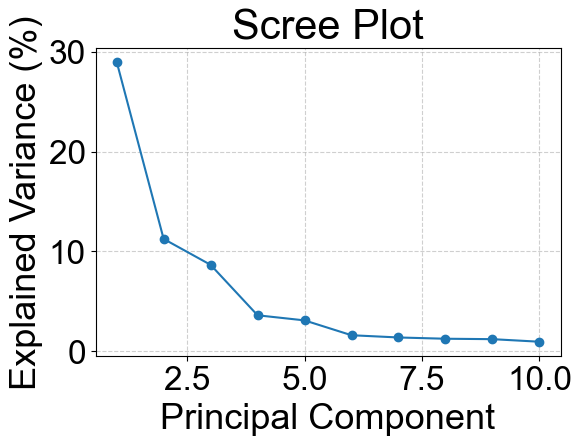

In [55]:
transposed_data = data.set_index("PG.Genes").transpose()

transposed_data = transposed_data.fillna(0)

valid_samples = [sample for sample in transposed_data.index if "_" in sample]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(row) for row in transposed_data.index]

colors = [condition_colors.get(condition, "#000000") for condition in sample_conditions]

adata = sc.AnnData(transposed_data.loc[valid_samples].values)
adata.obs["condition"] = sample_conditions

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=10)

explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance_ratio)+1),
         explained_variance_ratio*100, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

transposed_data.to_csv("Saliva_Cryopreserved_Patients_Library_Report_transposed.tsv", sep="\t")

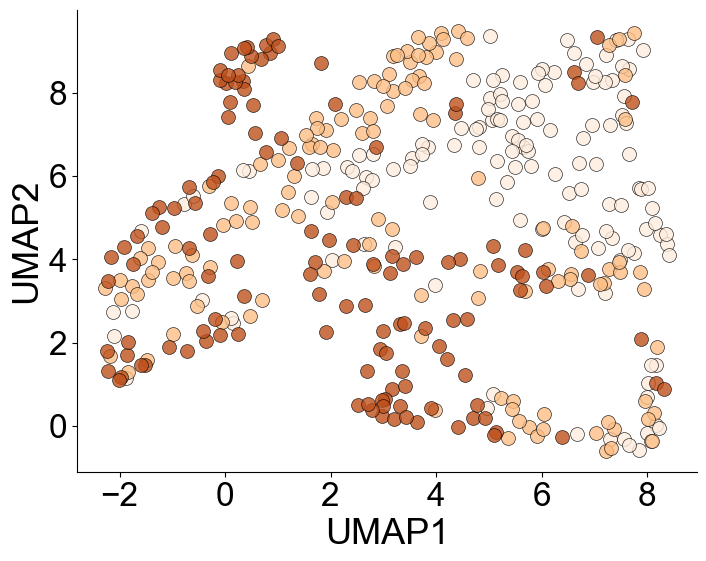

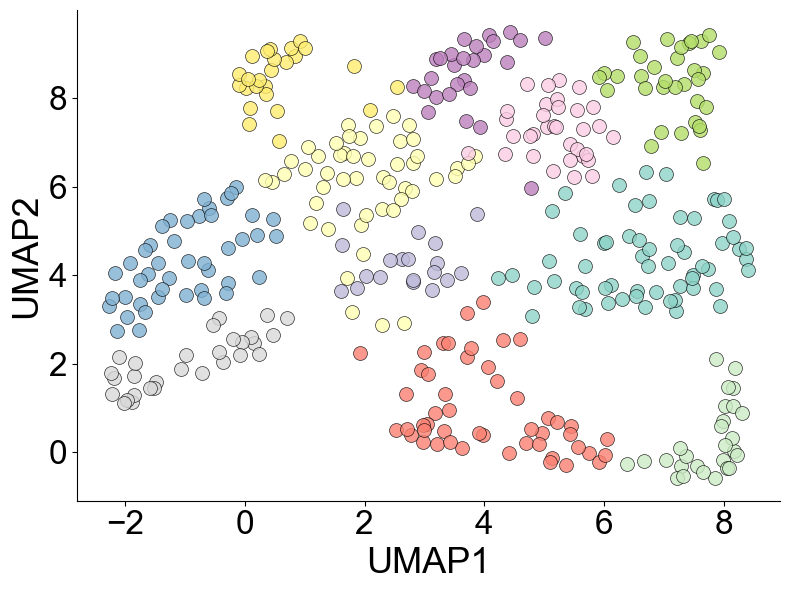

In [56]:
valid_samples = [sample for sample in transposed_data.index if "_" in sample]
filtered_data = transposed_data.loc[valid_samples]

condition_keywords = list(condition_colors.keys())

def extract_condition(row_name):
    for keyword in condition_keywords:
        if keyword in row_name:
            return keyword
    return "Unknown"

sample_conditions = [extract_condition(sample) for sample in valid_samples]

obs_data = pd.DataFrame({"condition": sample_conditions}, index=valid_samples)

adata = sc.AnnData(filtered_data.values, obs=obs_data, var=pd.DataFrame(index=filtered_data.columns))

sc.pp.log1p(adata)

sc.tl.pca(adata, n_comps=10)
sc.pp.neighbors(adata)

sc.tl.leiden(adata, resolution=1)


sc.tl.umap(adata, random_state=42)

umap_results = adata.obsm["X_umap"]
umap1 = umap_results[:, 0]
umap2 = umap_results[:, 1]




plt.figure(figsize=(8, 6))
for condition in np.unique(sample_conditions):
    mask = obs_data["condition"] == condition
    plt.scatter(umap1[mask], umap2[mask], label=condition,
                color=condition_colors.get(condition, "#000000"),
                alpha=0.8, s=100, edgecolor='black', linewidth=0.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("")
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(False)
plt.savefig("umap_condition_clean_axes.svg", dpi=300)

plt.show()

leiden_labels = adata.obs["leiden"]
palette = plt.cm.Set3(np.linspace(0, 1, len(sorted(leiden_labels.unique()))))

plt.figure(figsize=(8, 6))
for i, cluster in enumerate(sorted(leiden_labels.unique())):
    mask = leiden_labels == cluster
    plt.scatter(
        umap1[mask], umap2[mask],
        s=100, alpha=0.8, edgecolor='black', linewidth=0.5,
        color=palette[i]
    )

plt.xlabel("UMAP1", color='black')
plt.ylabel("UMAP2", color='black')

plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')


plt.tight_layout()
plt.savefig("leiden_clean_axes.svg", dpi=300)
plt.show()

In [57]:
group_counts = adata.obs.groupby(["condition", "leiden"]).size().unstack(level="leiden", fill_value=0)

print("Number of cells per Leiden cluster within each condition:")
print(group_counts)

Number of cells per Leiden cluster within each condition:
leiden                 0   1   2   3   4   5   6   7   8   9  10
condition                                                       
Control_OLDC          32  17   3   5  24  31   5   1  13   0   5
N0_EPF                17  21  12  22   5   0   8  26  10   2   6
Nodal_metastasis_WAS  11  11  34  17   4   2  16   0   4  23   8


/tmp/ipython-input-207943466.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = adata.obs.groupby(["condition", "leiden"]).size().unstack(level="leiden", fill_value=0)


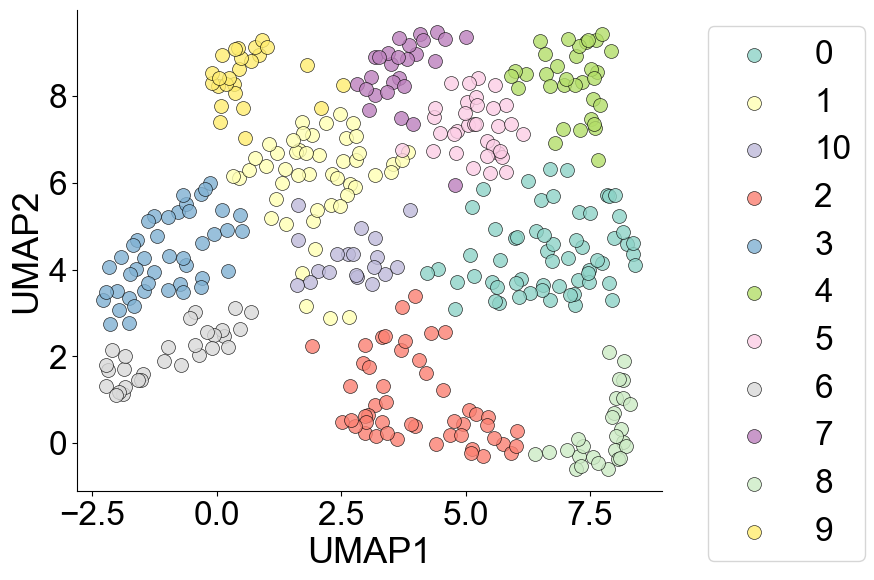

In [58]:
#Legend
leiden_labels = adata.obs["leiden"]
palette = plt.cm.Set3(np.linspace(0, 1, len(sorted(leiden_labels.unique()))))

plt.figure(figsize=(8.9, 6))
for i, cluster in enumerate(sorted(leiden_labels.unique())):
    mask = leiden_labels == cluster
    plt.scatter(
        umap1[mask], umap2[mask],
        label=f"{cluster}",
        s=100, alpha=0.8, edgecolor='black', linewidth=0.5,
        color=palette[i]
    )

plt.xlabel("UMAP1", color='black')
plt.ylabel("UMAP2", color='black')

plt.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.tight_layout()
plt.savefig("leiden_with_legend.svg", dpi=300)
plt.show()


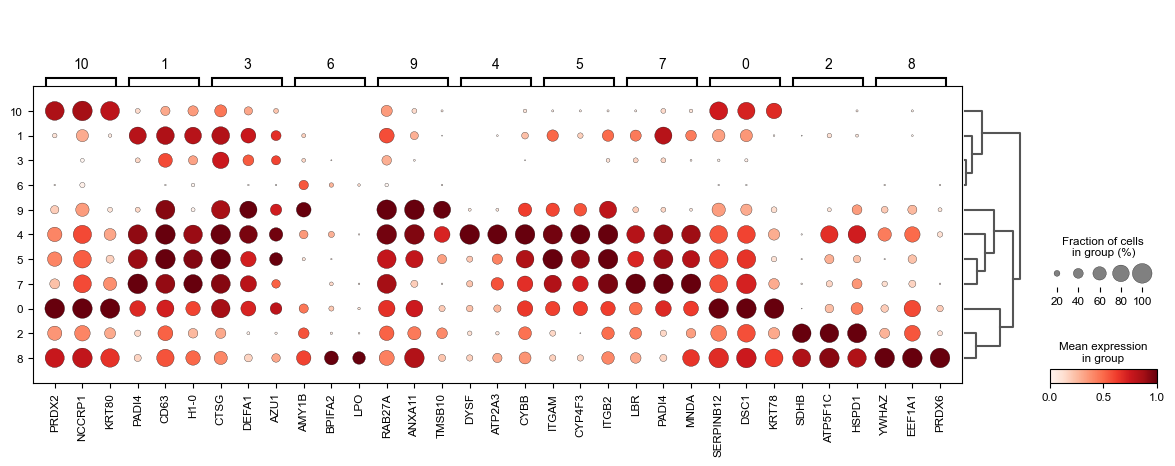

In [59]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

marker_genes = []
groups = adata.obs["leiden"].unique().tolist()

for group in groups:
    df = sc.get.rank_genes_groups_df(adata, group=group, key="dea_leiden")
    df = df.dropna(subset=["logfoldchanges", "pvals"])
    df = df[df["pvals_adj"] < 0.05]
    df = df.nlargest(5, "scores")
    marker_genes.extend(df["names"].tolist())

marker_genes = list(dict.fromkeys(marker_genes))

adata.var_names_make_unique()

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df["fold_change"] = 2 ** full_df["logfoldchanges"]
full_df.to_csv("DEG_leiden_with_FC.tsv", sep="\t", index=False)

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden",
    key="dea_leiden",
    n_genes=3, # Keep n_genes=5 to show top 5 per group
    standard_scale="var",
    dendrogram=True,
    cmap="Reds",
    show=True,
    save="_PG_dotplot_leidengroup_markers.svg"
)

In [60]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]


cluster_dict = {group: set(full_df[full_df["group"] == group]["names"])
                for group in adata.obs["leiden"].unique()}


exclusive_genes = {}
for group, genes in cluster_dict.items():
    other_genes = set().union(*[g for gname, g in cluster_dict.items() if gname != group])
    exclusive_genes[group] = genes - other_genes

exclusive_df = [(group, gene) for group, genes in exclusive_genes.items() for gene in genes]
exclusive_df = pd.DataFrame(exclusive_df, columns=["cluster", "gene"])
exclusive_df.to_csv("exclusive_genes_per_cluster.tsv", sep="\t", index=False)

exclusive_genes


{'4': {'ALDH3B1',
  'ATP8A1',
  'C4BPA',
  'C5AR1',
  'FCER1G',
  'FGR',
  'MGAM',
  'S100A12',
  'TMEM30A',
  'UNC13D',
  'VNN1'},
 '0': {'CHI3L1', 'CTSC', 'GGH', 'KRT15', 'KRT3', 'LOC100653049'},
 '5': set(),
 '3': {'MUCL1', 'PRH1'},
 '1': set(),
 '8': {'ACOX1',
  'ACTN4',
  'ACTR1A',
  'ADAR',
  'ALDH6A1',
  'AMPD3',
  'ANP32A',
  'ANXA8',
  'AP1G1',
  'APEX1',
  'APOA1',
  'ARF5',
  'ARHGDIB',
  'B2M',
  'BANF1',
  'BARGIN',
  'BPIFA2',
  'BSG',
  'C4A',
  'CAP1',
  'CAPG',
  'CBR1',
  'CCT7',
  'CCT8',
  'CD207',
  'CDC42',
  'CLIC1',
  'CLU',
  'CMAS',
  'CNN2',
  'COPA',
  'COPB1',
  'COPB2',
  'COPG1',
  'COPG2',
  'CORO7',
  'COTL1',
  'CRABP2',
  'CSTB',
  'CYB5R1',
  'DARS1',
  'DEF6',
  'DEK',
  'DMBT1',
  'DNM2',
  'DOCK2',
  'DYNC1H1',
  'EEF1D',
  'EEF1G',
  'EFHD2',
  'EHD4',
  'EIF4A1',
  'ELMO1',
  'EPRS1',
  'EZR',
  'FASN',
  'FERMT3',
  'FGA',
  'FMNL1',
  'FUBP3',
  'GMFG',
  'GPI',
  'GSTP1',
  'GYS1',
  'H6PD',
  'HDGF',
  'HNRNPA0',
  'HNRNPA2B1',
  'HNRNPAB',


Exclusise selected: {'4': ['VNN1', 'S100A12', 'C5AR1', 'FGR', 'ALDH3B1'], '0': ['KRT3', 'GGH', 'CHI3L1', 'CTSC', 'KRT15'], '3': ['MUCL1', 'PRH1'], '8': ['PRDX6', 'EIF4A1', 'CSTB', 'EZR', 'HSP90AB1'], '7': ['MMP9', 'MMP8', 'LCN2'], '2': ['CES1', 'GIMAP1', 'SOD2', 'NIPSNAP3A', 'CTSS'], '9': ['JAML']}
categories: 0, 1, 2, etc.
var_group_labels: 4, 0, 3, etc.


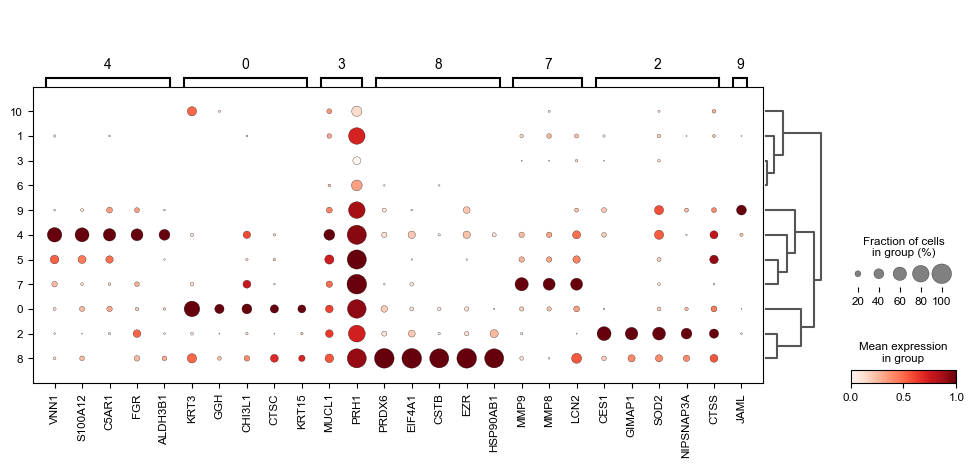

In [61]:
import scanpy as sc
import pandas as pd

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    key_added="dea_leiden"
)

full_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden").dropna()
full_df = full_df[full_df["pvals_adj"] < 0.05]

exclusive_genes = {}
for group in adata.obs["leiden"].unique():
    cluster_genes = set(full_df[full_df["group"] == group]["names"])
    other_genes = set(full_df[full_df["group"] != group]["names"])
    exclusive = cluster_genes - other_genes

    df = full_df[(full_df["group"] == group) & (full_df["names"].isin(exclusive))]
    df = df.sort_values("scores", ascending=False).head(5)

    if not df.empty:
        exclusive_genes[group] = df["names"].tolist()

exclusive_gene_list = [g for genes in exclusive_genes.values() for g in genes]

print("Exclusise selected:", exclusive_genes)

adata.var_names_make_unique()

sc.pl.dotplot(
    adata,
    var_names=exclusive_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="Reds",
    dendrogram=True,
    show=True,
    save="_PG_dotplot_leidengroup_exclusive.svg"
)

In [62]:
if "dea_leiden" in adata.uns:
    markers_df = sc.get.rank_genes_groups_df(adata, None, key="dea_leiden")

    significant_markers = markers_df[markers_df["pvals_adj"] < 0.05]

    print("\nCluster Marker Table (p_adj < 0.05):")
    print(significant_markers.head())  # Mostra os primeiros genes significativos

    significant_markers.to_csv("significant_leiden_cluster_markers_full_table.tsv", sep="\t", index=False)
    print("\nTabela filtrada salva como 'significant_leiden_cluster_markers_full_table.tsv'")


Cluster Marker Table (p_adj < 0.05):
  group      names     scores  logfoldchanges         pvals     pvals_adj
0     0  SERPINB12  11.563883        6.355994  6.280327e-31  4.873534e-28
1     0       DSC1  11.475478        5.944380  1.752071e-30  5.603963e-28
2     0      KRT78  11.415313        9.637795  3.506385e-30  5.603963e-28
3     0       FLG2  11.414085        8.623479  3.556252e-30  5.603963e-28
4     0     NCCRP1  11.399351        5.606953  4.212467e-30  5.603963e-28

Tabela filtrada salva como 'significant_leiden_cluster_markers_full_table.tsv'
